# Download and pre-process MNIST as a stub dataset for debugging and showcasing the framework

In [2]:
from torchvision.datasets import MNIST


MNIST(root="./datasets/", train=True, download=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 4645075.00it/s]


Extracting ./datasets/MNIST/raw/train-images-idx3-ubyte.gz to ./datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 310154.22it/s]


Extracting ./datasets/MNIST/raw/train-labels-idx1-ubyte.gz to ./datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2482727.75it/s]


Extracting ./datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to ./datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 4031004.82it/s]

Extracting ./datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./datasets/MNIST/raw



Dataset MNIST
    Number of datapoints: 60000
    Root location: ./datasets/
    Split: Train

# Pre-train dataset

In [6]:
from pathlib import Path
import random

from torchvision.datasets import MNIST
from torchvision.transforms import functional as TF


# Reproducible small translations for the second buffer image
random.seed(42)

out_dir_train = Path("./datasets/MNIST/pretrain/train")
out_dir_train.mkdir(parents=True, exist_ok=True)

dataset = MNIST(root="./datasets/", train=True, download=True)

shuffled_indices = list(range(len(dataset)))
random.shuffle(shuffled_indices)
train_indices = shuffled_indices[:300]
test_indices = shuffled_indices[300:600]
dataset = [dataset[idx] for idx in shuffled_indices]

num_images = 300
max_translation_px = 2


# Pre-train train (for pre-training)
for idx in train_indices:
    image, _ = dataset[idx]  # PIL grayscale image

    # Buffer 0: original image
    buffer0 = image

    # Buffer 1: translated copy of the same image
    dx = random.randint(-max_translation_px, max_translation_px)
    dy = random.randint(-max_translation_px, max_translation_px)
    buffer1 = TF.affine(
        image,
        angle=0.0,
        translate=[dx, dy],
        scale=1.0,
        shear=[0.0, 0.0],
        fill=0,
    )

    stem = f"mnist_{idx:04d}"
    buffer0.save(out_dir_train / f"{stem}_buffer0.png")
    buffer1.save(out_dir_train / f"{stem}_buffer1.png")

print(f"Saved {len(train_indices)} MNIST pairs to: {out_dir_train.resolve()}")


# Pre-train eval (for reconstruction eval of MAE)
out_dir_test = Path("./datasets/MNIST/pretrain/eval/")
out_dir_test.mkdir(parents=True, exist_ok=True)

for idx in test_indices:
    image, _ = dataset[idx]  # PIL grayscale image

    # Buffer 0: original image
    buffer0 = image

    # Buffer 1: translated copy of the same image
    dx = random.randint(-max_translation_px, max_translation_px)
    dy = random.randint(-max_translation_px, max_translation_px)
    buffer1 = TF.affine(
        image,
        angle=0.0,
        translate=[dx, dy],
        scale=1.0,
        shear=[0.0, 0.0],
        fill=0,
    )

    stem = f"mnist_{idx:04d}"
    buffer0.save(out_dir_test / f"{stem}_buffer0.png")
    buffer1.save(out_dir_test / f"{stem}_buffer1.png")

print(f"Saved {len(test_indices)} MNIST pairs to: {out_dir_test.resolve()}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 4773455.20it/s]


Extracting ./datasets/MNIST/raw/train-images-idx3-ubyte.gz to ./datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 312743.83it/s]


Extracting ./datasets/MNIST/raw/train-labels-idx1-ubyte.gz to ./datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2483077.18it/s]


Extracting ./datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to ./datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 2962757.20it/s]


Extracting ./datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./datasets/MNIST/raw

Saved 300 MNIST pairs to: /home/joaquin/phd/projects/aoi-ssl/datasets/MNIST/pretrain/train
Saved 300 MNIST pairs to: /home/joaquin/phd/projects/aoi-ssl/datasets/MNIST/pretrain/eval


# Fine-tune Dataset

In [8]:
from pathlib import Path
import random

import cv2
import numpy as np
from torchvision.datasets import MNIST
from torchvision.transforms import functional as TF


random.seed(42)
np.random.seed(42)

# Output layout
base_out = Path("./datasets/MNIST/finetune")
split_dirs = {
    "train": {
        "img": base_out / "train" / "img",
        "lbl": base_out / "train" / "lbl",
    },
    "val": {
        "img": base_out / "val" / "img",
        "lbl": base_out / "val" / "lbl",
    },
    "test": {
        "img": base_out / "test" / "img",
        "lbl": base_out / "test" / "lbl",
    },
}

for split in split_dirs.values():
    split["img"].mkdir(parents=True, exist_ok=True)
    split["lbl"].mkdir(parents=True, exist_ok=True)

# Optional cleanup so reruns don't mix old/new files
clean_existing = True
if clean_existing:
    for split in split_dirs.values():
        for folder in (split["img"], split["lbl"]):
            for p in folder.glob("*.png"):
                p.unlink()

# Build a pool from MNIST train+test and sample 300 unique images
train_ds = MNIST(root="./datasets/", train=True, download=True)
test_ds = MNIST(root="./datasets/", train=False, download=True)
pool = list(train_ds) + list(test_ds)

num_total = 300
indices = list(range(len(pool)))
random.shuffle(indices)
chosen_indices = indices[:num_total]

# 70/15/15 split
n_train = int(0.70 * num_total)
n_val = int(0.15 * num_total)
n_test = num_total - n_train - n_val

split_index_ranges = {
    "train": chosen_indices[:n_train],
    "val": chosen_indices[n_train:n_train + n_val],
    "test": chosen_indices[n_train + n_val:],
}

max_translation_px = 2

def add_random_circles_and_mask(base_img_u8: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns: (image_with_circles_u8, class_index_mask_u8)
    Classes: 0=background, 1=digit, 2=random circles
    """
    h, w = base_img_u8.shape

    # Class 1 from grayscale image support (digit foreground)
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[base_img_u8 > 0] = 1

    # Copy image and add circles for class 2
    image_with_circles = base_img_u8.copy()
    circle_mask = np.zeros((h, w), dtype=np.uint8)

    num_circles = random.randint(1, 3)
    for _ in range(num_circles):
        radius = random.randint(3, 5)
        cx = random.randint(radius, w - radius - 1)
        cy = random.randint(radius, h - radius - 1)
        cv2.circle(circle_mask, (cx, cy), radius, color=1, thickness=-1)
        cv2.circle(image_with_circles, (cx, cy), radius, color=255, thickness=-1)

    # Class 2 overrides class 1 where circles exist
    mask[circle_mask == 1] = 2
    return image_with_circles, mask

for split_name, split_indices in split_index_ranges.items():
    img_dir = split_dirs[split_name]["img"]
    lbl_dir = split_dirs[split_name]["lbl"]

    for i, pool_idx in enumerate(split_indices):
        image_pil, _ = pool[pool_idx]  # PIL grayscale image
        image_u8 = np.array(image_pil, dtype=np.uint8)

        # Add synthetic class-2 circles and produce class-index mask
        image_aug_u8, mask_u8 = add_random_circles_and_mask(image_u8)

        # Buffer 0: augmented base image
        buffer0 = image_aug_u8

        # Buffer 1: small translated copy
        dx = random.randint(-max_translation_px, max_translation_px)
        dy = random.randint(-max_translation_px, max_translation_px)
        buffer1_pil = TF.affine(
            img=TF.to_pil_image(buffer0),
            angle=0.0,
            translate=[dx, dy],
            scale=1.0,
            shear=[0.0, 0.0],
            fill=0,
        )
        buffer1 = np.array(buffer1_pil, dtype=np.uint8)

        stem = f"mnist_{split_name}_{i:04d}"
        cv2.imwrite(str(img_dir / f"{stem}_buffer0.png"), buffer0)
        cv2.imwrite(str(img_dir / f"{stem}_buffer1.png"), buffer1)
        cv2.imwrite(str(lbl_dir / f"{stem}.png"), mask_u8)

print("Created MNIST finetune dataset:")
print(f"  train: {n_train} samples")
print(f"  val:   {n_val} samples")
print(f"  test:  {n_test} samples")
print(f"Saved under: {base_out.resolve()}")

Created MNIST finetune dataset:
  train: 210 samples
  val:   45 samples
  test:  45 samples
Saved under: /home/joaquin/phd/projects/aoi-ssl/datasets/MNIST/finetune


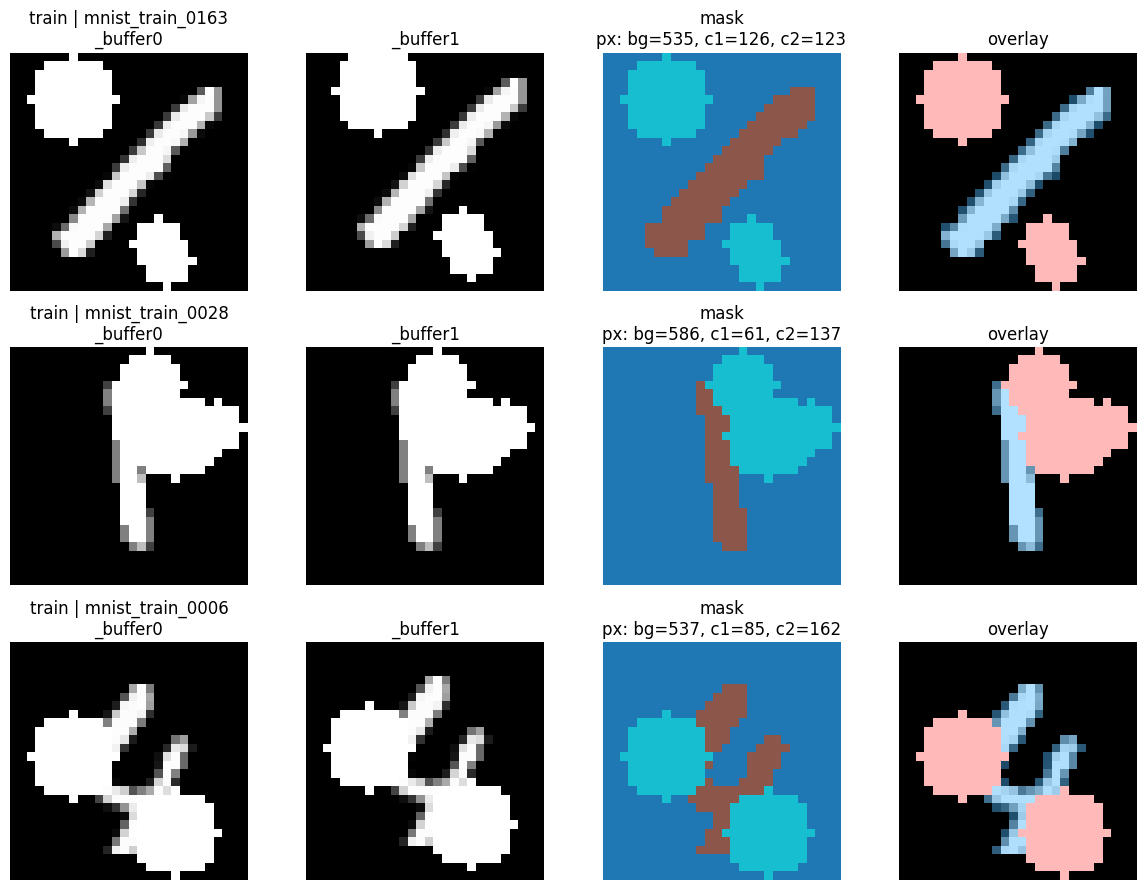

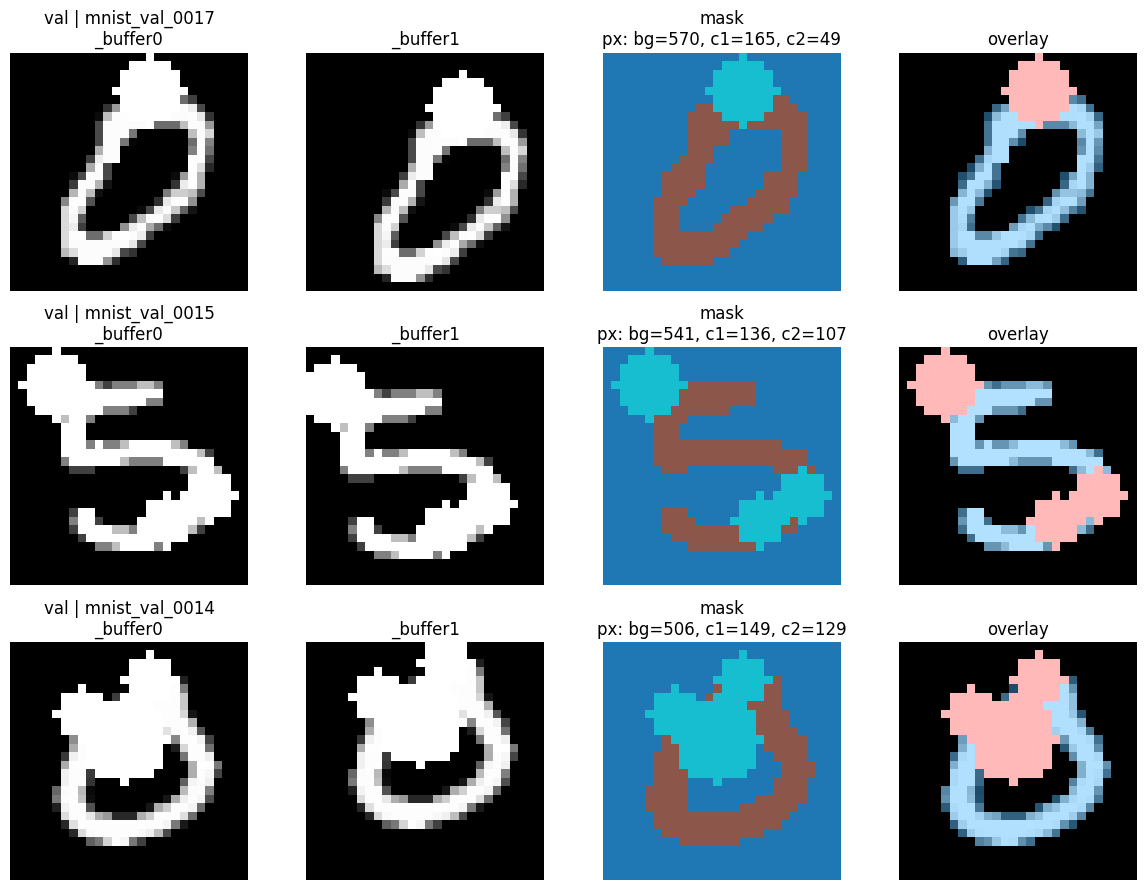

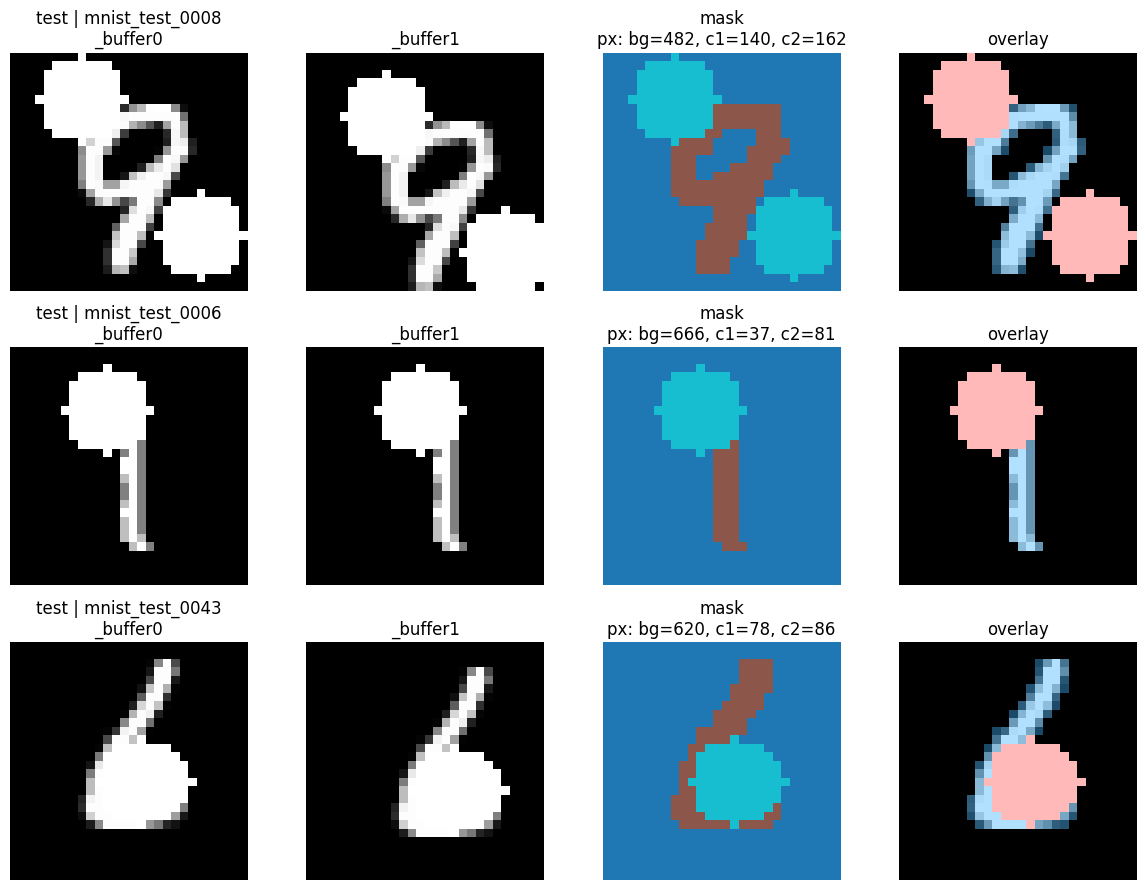

Legend: class 0=background, class 1=digit, class 2=random circles


In [9]:
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np


base_out = Path("./datasets/MNIST/finetune")
splits = ["train", "val", "test"]
samples_per_split = 3
random.seed(42)

# Colors for classes: 0=background, 1=digit, 2=circles
class_colors = np.array(
    [
        [0, 0, 0],        # background -> black
        [60, 180, 255],   # digit -> orange-ish
        [255, 80, 80],    # circles -> red-ish
    ],
    dtype=np.uint8,
 )

for split in splits:
    img_dir = base_out / split / "img"
    lbl_dir = base_out / split / "lbl"

    buffer0_paths = sorted(img_dir.glob("*_buffer0.png"))
    if not buffer0_paths:
        print(f"[{split}] No images found in {img_dir}")
        continue

    picked = random.sample(buffer0_paths, k=min(samples_per_split, len(buffer0_paths)))

    fig, axes = plt.subplots(len(picked), 4, figsize=(12, 3 * len(picked)))
    if len(picked) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, buffer0_path in enumerate(picked):
        stem = buffer0_path.name.replace("_buffer0.png", "")
        buffer1_path = img_dir / f"{stem}_buffer1.png"
        mask_path = lbl_dir / f"{stem}.png"

        img0 = cv2.imread(str(buffer0_path), cv2.IMREAD_GRAYSCALE)
        img1 = cv2.imread(str(buffer1_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if img0 is None or img1 is None or mask is None:
            print(f"Skipping {stem}: missing buffer/mask")
            continue

        # Render mask using class colors
        mask_rgb = class_colors[np.clip(mask, 0, 2)]

        # Overlay mask on buffer0
        img0_rgb = cv2.cvtColor(img0, cv2.COLOR_GRAY2RGB)
        overlay = cv2.addWeighted(img0_rgb, 0.6, mask_rgb, 0.4, 0)

        # Quick class pixel counts for sanity-checking
        class_counts = {cls: int((mask == cls).sum()) for cls in [0, 1, 2]}

        axes[row, 0].imshow(img0, cmap="gray")
        axes[row, 0].set_title(f"{split} | {stem}\n_buffer0")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(img1, cmap="gray")
        axes[row, 1].set_title("_buffer1")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(mask, cmap="tab10", vmin=0, vmax=2)
        axes[row, 2].set_title(
            f"mask\npx: bg={class_counts[0]}, c1={class_counts[1]}, c2={class_counts[2]}"
        )
        axes[row, 2].axis("off")

        axes[row, 3].imshow(overlay)
        axes[row, 3].set_title("overlay")
        axes[row, 3].axis("off")

    plt.tight_layout()
    plt.show()

print("Legend: class 0=background, class 1=digit, class 2=random circles")